In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import numpy as np

C:\Users\mirna\anaconda3\envs\network_env\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
bioprofileOG = pd.read_excel("../DonorDataOG/Bioprofile_Query_OG.xlsx")
destructive = pd.read_excel("../DonorDataOG/Destructive_Analysis_Query_OG.xlsx").drop('Race', axis=1)
facts = pd.read_excel("../DonorDataOG/Facts_of_Death_OG.xlsx")

In [3]:
bioprofileOG

,TXSTDonorNumber,Curated,Current Facility,AgeAtDeath,Sex,Race,HispanicOrigin,Height(cm),HeightEstimated,CadaverStature(cm),Weight(lb),WeightEstimated,CadaverWeight(lbs)
0,2008.001,True,GEFARL,81,Male,Hispanic,Unknown,168.0,False,169.0,140.0,False,NaN
1,2008.002,True,GEFARL,65,Female,White,Non-hispanic,NaN,False,154.0,NaN,False,330.0
2,2008.003,True,GEFARL,75,Male,White,Non-hispanic,175.0,False,175.0,293.0,False,293.0
3,2009.001,True,GEFARL,49,Male,White,Non-hispanic,180.0,True,180.0,150.0,True,NaN
4,2009.002,True,GEFARL,91,Male,White,Non-hispanic,178.0,True,178.0,130.0,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
917,2025.012,False,FARF Surface,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False,NaN
918,2025.013,False,FARF Surface,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False,NaN
919,2025.014,False,FARF Surface,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False,NaN
920,2025.015,False,FARF Surface,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False,NaN


In [4]:
facts

,FactsOfDeathID,TXSTDonorNumber,AgeAtDeath,DateOfDeath,DODSpecify,ImmediateCOD,MannerOfDeath,LocationOfDeath,FacilityOfDeath,CityOfDeath,StateOfDeath,RecordEntryBy,RecordEntryDate,RecordAuditBy,RecordAuditDate,RecordUpdateBy,RecordUpdateDate
0,1,2008.001,81,2008-04-05,NaN,Hypertensive Cardiovascular Disease,Natural,NaN,NaN,NaN,NaN,LF (TLT),2019,HJS,9/16/2024,NaN,NaN
1,2,2008.002,65,2008-09-30,NaN,Unknown (FACTS did not receive records),Natural,NaN,NaN,NaN,NaN,LF (TLT),2019,HJS,9/16/2024,NaN,NaN
2,3,2008.003,75,2008-10-11,NaN,Unknown (FACTS did not receive records),Natural,NaN,NaN,NaN,NaN,LF (TLT),2019,HJS,9/16/2024,NaN,NaN
3,4,2009.001,49,2009-01-26,NaN,Gun shot wound to the head,Suicide,NaN,NaN,NaN,NaN,LF (TLT),2019,NaN,NaN,NaN,NaN
4,5,2009.002,91,2009-01-26,NaN,Gun shot wound to the head,Homicide,NaN,NaN,NaN,NaN,LF (TLT),2019,NaN,NaN,TPG,10/19/2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
917,1006,2025.012,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
918,1007,2025.013,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
919,1008,2025.014,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
920,1009,2025.015,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
destructive

,TXSTDonorNumber,AgeAtDeath,Sex,HispanicOrigin,Researchers,Destructive Sampling,SamplingType,ElementsSampled,SpecifySamples
0,2011.014,51,Male,Unknown,Nicholas P Herrmann,True,1,1,Hair taken from scalp
1,2020.006,80,Male,Mexican,Hailey Collord-Stalder,True,8,8,Right side. Proximal halves of long bones did ...
2,2013.014,58,Male,Non-hispanic,Lauren Meckel,True,50,50,Tooth #27 (root only)
3,2013.018,91,Female,Non-hispanic,Lauren Meckel,True,51,51,Tooth #13 (root only)
4,2013.025,62,Male,Non-hispanic,Lauren Meckel,True,55,55,Tooth #28 (root only)
...,...,...,...,...,...,...,...,...,...
695,2024.021,64,Male,Non-hispanic,"Tim Gocha, Angi Christensen, Brian Spatola, Ma...",True,20376,20376,All bones impacted on lateral surface
696,2024.027,75,Male,Non-hispanic,"Tim Gocha, Angi Christensen, Brian Spatola, Ma...",True,20377,20377,Humerus and femur impacted on anterior surface...
697,2024.029,71,Male,Other,"Tim Gocha, Angi Christensen, Brian Spatola, Ma...",True,20378,20378,All bones impacted on lateral surface
698,2024.037,71,Male,Non-hispanic,"Tim Gocha, Angi Christensen, Brian Spatola, Ma...",True,20379,20379,All bones impacted on posterior surface


In [28]:
# Step 1 — Convert column to numeric, coercing errors to NaN
bioprofileOG['AgeAtDeath'] = pd.to_numeric(bioprofileOG['AgeAtDeath'], errors='coerce')

# Step 2 — Keep only numeric rows
bioprofileOG = bioprofileOG[bioprofileOG['AgeAtDeath'].notna()].copy()

# Step 3 — Keep only ages 18 and above
bioprofileOG_adult = bioprofileOG[bioprofileOG['AgeAtDeath'] >= 18].copy()

# Step 4 — Check unique ages
bioprofileOG_adult['AgeAtDeath'].unique()

array([ 81.,  65.,  75.,  49.,  91.,  31.,  87.,  60.,  77.,  66.,  53.,
        58.,  76.,  79.,  74.,  71.,  67.,  57.,  46.,  63.,  32.,  54.,
        70.,  64.,  40.,  52.,  68.,  80.,  51.,  84.,  56.,  33.,  78.,
        88.,  59.,  48.,  85.,  62.,  47.,  90.,  18.,  34.,  42.,  83.,
        44., 102.,  72.,  50.,  43.,  89.,  45.,  69.,  55.,  86.,  61.,
        94.,  73.,  29.,  23.,  20.,  82.,  39.,  93.,  95.,  21.,  97.,
        22.,  30., 103.,  28.,  92.,  98.,  35., 100.,  27.,  41.,  38.,
       107.,  36.,  26.,  25.,  96.])

In [29]:
df_merged = bioprofileOG_adult.merge(destructive, on = ['TXSTDonorNumber', 'AgeAtDeath', 'Sex', 'HispanicOrigin'], how='inner')
df_merged

,TXSTDonorNumber,Curated,Current Facility,AgeAtDeath,Sex,Race,HispanicOrigin,Height(cm),HeightEstimated,CadaverStature(cm),Weight(lb),WeightEstimated,CadaverWeight(lbs),Researchers,Destructive Sampling,SamplingType,ElementsSampled,SpecifySamples
0,2008.001,True,GEFARL,81.0,Male,Hispanic,Unknown,168.0,False,169.0,140.0,False,NaN,Shyamalika Gopalan,True,256,256,1/8 hole on the palletar surface of the right ...
1,2008.001,True,GEFARL,81.0,Male,Hispanic,Unknown,168.0,False,169.0,140.0,False,NaN,Sophia Mavroudas,True,6793,6793,Right 6th rib midshaft
2,2008.002,True,GEFARL,65.0,Female,White,Non-hispanic,NaN,False,154.0,NaN,False,330.0,Nicholas P Herrmann,True,199,199,Tooth #25 and intermediate manual phalanx
3,2008.002,True,GEFARL,65.0,Female,White,Non-hispanic,NaN,False,154.0,NaN,False,330.0,Sophia Mavroudas,True,6794,6794,Right 6th rib midshaft
4,2008.002,True,GEFARL,65.0,Female,White,Non-hispanic,NaN,False,154.0,NaN,False,330.0,"Carina Marques, Benoit Bertrand, Timothy Gocha",True,19928,19928,Tooth 22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,2024.037,False,FARF Surface,71.0,Male,White,Non-hispanic,180.0,True,177.0,220.0,True,139.0,"Tim Gocha, Angi Christensen, Brian Spatola, Ma...",True,20379,20379,All bones impacted on posterior surface
696,2024.038,False,FARF Surface,73.0,Male,White,Non-hispanic,185.0,True,181.0,175.0,True,160.0,"Tim Gocha, Angi Christensen, Brian Spatola, Ma...",True,20380,20380,All bones impacted on posterior surface
697,2024.040,False,FARF Surface,71.0,Female,White,Non-hispanic,157.0,True,157.0,133.0,False,103.0,"Danny Wescott, Mariah Moe, Sophia Mavroudas",True,20113,20113,Whole Body
698,2024.041,False,FARF Surface,81.0,Female,White,Non-hispanic,157.0,False,159.0,130.0,False,135.0,"Danny Wescott, Mariah Moe, Sophia Mavroudas",True,20114,20114,Whole Body


In [30]:
df_merged.columns

Index(['TXSTDonorNumber', 'Curated', 'Current Facility', 'AgeAtDeath', 'Sex',
       'Race', 'HispanicOrigin', 'Height(cm)', 'HeightEstimated',
       'CadaverStature(cm)', 'Weight(lb)', 'WeightEstimated',
       'CadaverWeight(lbs)', 'Researchers', 'Destructive Sampling',
       'SamplingType', 'ElementsSampled', 'SpecifySamples'],
      dtype='object')

In [31]:
# Step 1 — Convert column to numeric, coercing errors to NaN
facts['AgeAtDeath'] = pd.to_numeric(facts['AgeAtDeath'], errors='coerce')

# Step 2 — Keep only numeric rows
facts = facts[facts['AgeAtDeath'].notna()].copy()

# Step 3 — Keep only ages 18 and above
facts_adult = facts[facts['AgeAtDeath'] >= 18].copy()

# Step 4 — Check unique ages
facts_adult['AgeAtDeath'].unique()

array([ 81.,  65.,  75.,  49.,  91.,  31.,  87.,  60.,  77.,  66.,  53.,
        58.,  76.,  79.,  74.,  71.,  67.,  57.,  46.,  63.,  32.,  54.,
        70.,  64.,  40.,  52.,  68.,  80.,  62.,  78.,  51.,  73.,  50.,
        69.,  55.,  48.,  83.,  88.,  85.,  59.,  92.,  39.,  94.,  82.,
        90.,  29.,  84.,  56.,  61.,  42.,  35.,  34.,  47.,  18.,  44.,
       102.,  72.,  43.,  89.,  45.,  86.,  23.,  20.,  93.,  95.,  21.,
        97.,  22.,  30., 103.,  28.,  98.,  33., 100.,  27.,  41.,  38.,
       107.,  36.,  26.,  25.,  96.])

In [32]:
df_merged = df_merged.merge(facts_adult, on = ['TXSTDonorNumber', 'AgeAtDeath'], how='inner')
df_merged

,TXSTDonorNumber,Curated,Current Facility,AgeAtDeath,Sex,Race,HispanicOrigin,Height(cm),HeightEstimated,CadaverStature(cm),...,LocationOfDeath,FacilityOfDeath,CityOfDeath,StateOfDeath,RecordEntryBy,RecordEntryDate,RecordAuditBy,RecordAuditDate,RecordUpdateBy,RecordUpdateDate
0,2008.001,True,GEFARL,81.0,Male,Hispanic,Unknown,168.0,False,169.0,...,NaN,NaN,NaN,NaN,LF (TLT),2019,HJS,9/16/2024,NaN,NaN
1,2008.001,True,GEFARL,81.0,Male,Hispanic,Unknown,168.0,False,169.0,...,NaN,NaN,NaN,NaN,LF (TLT),2019,HJS,9/16/2024,NaN,NaN
2,2008.002,True,GEFARL,65.0,Female,White,Non-hispanic,NaN,False,154.0,...,NaN,NaN,NaN,NaN,LF (TLT),2019,HJS,9/16/2024,NaN,NaN
3,2008.002,True,GEFARL,65.0,Female,White,Non-hispanic,NaN,False,154.0,...,NaN,NaN,NaN,NaN,LF (TLT),2019,HJS,9/16/2024,NaN,NaN
4,2008.002,True,GEFARL,65.0,Female,White,Non-hispanic,NaN,False,154.0,...,NaN,NaN,NaN,NaN,LF (TLT),2019,HJS,9/16/2024,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,2024.037,False,FARF Surface,71.0,Male,White,Non-hispanic,180.0,True,177.0,...,Private residence,1220 S. Palmera Dr.,La Feria,TX,HJS,8/6/2024,HJS,9/13/2024,NaN,NaN
696,2024.038,False,FARF Surface,73.0,Male,White,Non-hispanic,185.0,True,181.0,...,Hospital ER/Outpatient,Stillwater Medical-Blackwell,Blackwell,OK,HJS,8/5/2024,HJS,8/19/2024,NaN,NaN
697,2024.040,False,FARF Surface,71.0,Female,White,Non-hispanic,157.0,True,157.0,...,Private residence,309 E 11th St Apt 112,Austin,TX,HJS,9/6/2024,HJS,12/10/2024,NaN,NaN
698,2024.041,False,FARF Surface,81.0,Female,White,Non-hispanic,157.0,False,159.0,...,Private residence,30203 Doerner Ln.,Magnolia,TX,HJS,9/6/2024,HJS,9/13/2024,NaN,NaN


In [33]:
df_merged.to_csv('BioProfile_Destructive_Facts.csv', index=False)

In [34]:
# Drop columns with all missing or no variation
df_merged = df_merged.dropna(axis=1, how="all")
df_merged = df_merged.loc[:, df_merged.nunique() > 1]


In [35]:
df_2015 = df_merged[df_merged['TXSTDonorNumber'].astype(str).str.contains('2015', na=False)].copy()
df_2015.to_csv('BioProfile_Destructive_Facts_2015.csv', index=False)
df_2015

,TXSTDonorNumber,Curated,Current Facility,AgeAtDeath,Sex,Race,HispanicOrigin,Height(cm),HeightEstimated,CadaverStature(cm),...,LocationOfDeath,FacilityOfDeath,CityOfDeath,StateOfDeath,RecordEntryBy,RecordEntryDate,RecordAuditBy,RecordAuditDate,RecordUpdateBy,RecordUpdateDate
379,2015.001,True,GEFARL,59.0,Male,White,Non-hispanic,183.0,False,179.0,...,Hospital ER,Houston Northwest Medical Center,Houston,TX,Import,7/20/2020,TLT,7/31/2020,NaN,NaN
380,2015.001,True,GEFARL,59.0,Male,White,Non-hispanic,183.0,False,179.0,...,Hospital ER,Houston Northwest Medical Center,Houston,TX,Import,7/20/2020,TLT,7/31/2020,NaN,NaN
381,2015.001,True,GEFARL,59.0,Male,White,Non-hispanic,183.0,False,179.0,...,Hospital ER,Houston Northwest Medical Center,Houston,TX,Import,7/20/2020,TLT,7/31/2020,NaN,NaN
382,2015.001,True,GEFARL,59.0,Male,White,Non-hispanic,183.0,False,179.0,...,Hospital ER,Houston Northwest Medical Center,Houston,TX,Import,7/20/2020,TLT,7/31/2020,NaN,NaN
383,2015.001,True,GEFARL,59.0,Male,White,Non-hispanic,183.0,False,179.0,...,Hospital ER,Houston Northwest Medical Center,Houston,TX,Import,7/20/2020,TLT,7/31/2020,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469,2015.065,True,GEFARL,59.0,Male,White,Non-hispanic,NaN,False,179.0,...,Other,2145 East Highway 80,Mesquite,TX,Import,7/20/2020,TLT,8/16/2020,NaN,NaN
470,2015.066,True,GEFARL,56.0,Female,White,Non-hispanic,170.0,False,165.0,...,Nursing home/Long Term Care Facility,Stonebriar Nursing & Rehab,Austin,TX,Import,7/20/2020,TLT,8/16/2020,NaN,NaN
471,2015.067,True,GEFARL,65.0,Female,White,Non-hispanic,173.0,False,175.0,...,Private residence,NaN,Floresville,TX,Import,7/20/2020,TLT,8/16/2020,NaN,NaN
472,2015.068,True,GEFARL,62.0,Male,White,Non-hispanic,178.0,False,168.0,...,Hospital inpatient,Methodist Stone Oak Hospital,San Antonio,TX,Import,7/20/2020,TLT,8/16/2020,NaN,NaN


In [36]:
missing_table = pd.DataFrame({
    'MissingCount': df_merged.isnull().sum(),
    'MissingPercent': df_merged.isnull().mean() * 100
}).sort_values('MissingPercent', ascending=False)
missing_table


,MissingCount,MissingPercent
RecordUpdateDate,670,95.714286
RecordUpdateBy,670,95.714286
CadaverWeight(lbs),414,59.142857
RecordAuditDate,305,43.571429
RecordAuditBy,305,43.571429
FacilityOfDeath,271,38.714286
DODSpecify,254,36.285714
LocationOfDeath,71,10.142857
CityOfDeath,64,9.142857
StateOfDeath,63,9.000000


In [8]:
intake = pd.read_excel("../DonorDataOG/Intake_OG.xlsx")
life = pd.read_excel("../DonorDataOG/Life_History_Query_OG.xlsx")
research = pd.read_excel("../DonorDataOG/Research_History_OG.xlsx")

weather = pd.read_excel("../2015 Freeman Ranch Weather Data.xlsx", header=0)
placement = pd.read_excel("../DonorDataOG/Donor_Placement_Info_OG.xlsx")

In [9]:
print(life.shape)
print(intake.shape)
print(research.shape)
print(weather.shape)
print(placement.shape)


(922, 15)
(923, 46)
(13388, 23)
(16629, 38)
(887, 17)


In [38]:
# Get the list of columns in each dataframe
intake_cols = set(intake.columns)
life_cols = set(life.columns)

# Find overlapping columns
common_cols = list(intake_cols.intersection(life_cols))
common_cols

['RecordUpdateBy',
 'RecordAuditBy',
 'RecordAuditDate',
 'RecordEntryBy',
 'TXSTDonorNumber',
 'RecordEntryDate']

In [39]:
df_merged_2 = life.merge(
    intake,
    on=common_cols,
    how='outer',  # keep only rows present in both datasets
)

# Check merged columns
df_merged_2

,TXSTDonorNumber,AgeAtDeath,DateOfDeath,DODSpecify,ImmediateCOD,MannerOfDeath,LocationOfDeath,FacilityOfDeath,CityOfDeath,StateOfDeath,...,ThoracicAutopsy,SpinalAutopsy,OrganDonor,DonatedEyes,DonatedSkin,DonatedBones,DonatedInternalOrgans,DonatedBy,RecordUpdateDate,Paperless
0,2023.065,56,2023-12-04,Found,"Toxic Effects of Fentanyl, Methamphetamine, ci...",Accidental,Private residence,12433 Dessau Rd,Austin,TX,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023.055,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,No,False,False,False,False,NaN,1/15/2024,False
2,2024.045,91,2024-09-28,Actual,Chronic Respiratory Failure,Natural,Hospital inpatient,Baylor Scott and White Hospital- Round Rock,Round Rock,TX,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023.062,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,No,False,False,False,False,NaN,1/29/2024,False
4,2023.058,89,2023-11-16,Actual,COPD,Natural,Nursing home/Long Term Care Facility,Brownwood Nursing and Rehabilitation LP,Brownwood,TX,...,False,False,No,False,False,False,False,NaN,1/29/2024,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1420,2025.013,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,NaN,False,False,False,False,NaN,NaN,False
1421,2025.014,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,NaN,False,False,False,False,NaN,NaN,False
1422,2025.015,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,NaN,False,False,False,False,NaN,NaN,False
1423,2025.016,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,NaN,False,False,False,False,NaN,NaN,False


In [19]:
df_merged_2 = df_merged_2.merge(
    research,
    on=['TXSTDonorNumber'],
    how='inner',  # keep only rows present in both datasets
)

# Check merged columns
df_merged_2

,TXSTDonorNumber,AgeAtDeath,DateOfDeath,DODSpecify,ImmediateCOD,MannerOfDeath,LocationOfDeath,FacilityOfDeath,CityOfDeath,StateOfDeath,...,ImagingType,SpecifyImaging/Elements,StartDateofResearch,EndDateofResearch,Funded,FundingType,SpecifyFunding,Publications,PublicationInformation,Notes
0,2008.001,81,2008-04-05,NaN,Hypertensive Cardiovascular Disease,Natural,NaN,NaN,NaN,NaN,...,NaN,NaN,2016,2019,True,Grant,NIJ Grant #2016-DN-BX-0011 and NSF Grant #1753951,True,https://doi.org/10.1101/801647,NaN
1,2008.001,81,2008-04-05,NaN,Hypertensive Cardiovascular Disease,Natural,NaN,NaN,NaN,NaN,...,NaN,NaN,07/14/2020,07/14/2020,False,NaN,NaN,False,NaN,NaN
2,2008.001,81,2008-04-05,NaN,Hypertensive Cardiovascular Disease,Natural,NaN,NaN,NaN,NaN,...,NaN,NaN,08/2020,12/2020,False,NaN,NaN,False,NaN,NaN
3,2008.001,81,2008-04-05,NaN,Hypertensive Cardiovascular Disease,Natural,NaN,NaN,NaN,NaN,...,NaN,NaN,02/24/2020,NaN,False,NaN,NaN,False,NaN,NaN
4,2008.001,81,2008-04-05,NaN,Hypertensive Cardiovascular Disease,Natural,NaN,NaN,NaN,NaN,...,NaN,NaN,11/06/2019,11/06/2019,False,NaN,NaN,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6286,2024.029,71,2024-05-13,Actual,Malignant Neoplasm of Stomach,Natural,Private residence,3921 Northaven Trail,New Braunfels,TX,...,NaN,NaN,11/14/2024,11/14/2024,False,NaN,NaN,False,NaN,"The left humerus, femur, and tibia were used f..."
6287,2024.037,71,2024-07-19,Actual,Due to Complications of Diabetes Mellitus and ...,Natural,Private residence,1220 S. Palmera Dr.,La Feria,TX,...,NaN,NaN,11/14/2024,11/14/2024,False,NaN,NaN,False,NaN,"The left humerus, femur, and tibia were used f..."
6288,2024.038,73,2024-07-25,Actual,Acute Coronary Insufficiency,Natural,Hospital ER/Outpatient,Stillwater Medical-Blackwell,Blackwell,OK,...,NaN,NaN,11/14/2024,11/14/2024,False,NaN,NaN,False,NaN,"The left humerus, femur, and tibia were used f..."
6289,2024.040,71,2024-08-23,Found,Atherosclerotic and Hypertensive Cardiovascula...,Natural,Private residence,309 E 11th St Apt 112,Austin,TX,...,NaN,NaN,9/24/2024,9/26/2024,True,Grant,NIJ,False,NaN,"2024.040 - On 9/24/24, the donor was placed in..."


In [40]:
df_merged_2 = df_merged_2.merge(
    placement,
    left_on=['TXSTDonorNumber'],
    right_on=['TXSTDSC #'],
    how='outer',  # keep only rows present in both datasets
)

# Check merged columns
df_merged_2

,TXSTDonorNumber,AgeAtDeath,DateOfDeath,DODSpecify,ImmediateCOD,MannerOfDeath,LocationOfDeath,FacilityOfDeath,CityOfDeath,StateOfDeath,...,State,Donation.1,Curated,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
0,2008.001,81,2008-04-05,NaN,Hypertensive Cardiovascular Disease,Natural,NaN,NaN,NaN,NaN,...,NaN,NaN,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2008.002,65,2008-09-30,NaN,Unknown (FACTS did not receive records),Natural,NaN,NaN,NaN,NaN,...,NaN,NaN,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2008.003,75,2008-10-11,NaN,Unknown (FACTS did not receive records),Natural,NaN,NaN,NaN,NaN,...,NaN,NaN,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009.001,49,2009-01-26,NaN,Gun shot wound to the head,Suicide,NaN,NaN,NaN,NaN,...,NaN,NaN,Y,on loan,NaN,NaN,NaN,NaN,NaN,NaN
4,2009.002,91,2009-01-26,NaN,Gun shot wound to the head,Homicide,NaN,NaN,NaN,NaN,...,NaN,NaN,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1422,2025.013,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1423,2025.014,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1424,2025.015,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1425,2025.016,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
df_merged_2.to_csv('Life_Intake_Research_Placement.csv', index=False)

In [43]:
#df_2015 = df_merged_2[df_merged_2['TXSTDonorNumber'].astype(str).str.contains('2015', na=False)].copy()
df_2015.to_csv('Life_Intake_Research_Placement.csv', index=False)
df_2015

,TXSTDonorNumber,AgeAtDeath,DateOfDeath,DODSpecify,ImmediateCOD,MannerOfDeath,LocationOfDeath,FacilityOfDeath,CityOfDeath,StateOfDeath,...,State,Donation.1,Curated,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
312,2015.001,59,2015-01-05,Actual,Atherosclerotic cardiovascular disease,Natural,Hospital ER,Houston Northwest Medical Center,Houston,TX,...,TX,NOK,Y,Surface,9/27/2018 brought to ORPL,NaN,NaN,NaN,NaN,NaN
313,2015.001,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,TX,NOK,Y,Surface,9/27/2018 brought to ORPL,NaN,NaN,NaN,NaN,NaN
314,2015.002,82,2015-01-12,Actual,Closed head Injury (Due to fall),Accident,Hospital inpatient,University Hospital,San Antonio,TX,...,TX,NOK,Y,Freezer,Novem 2017 brought to ORPL,Curated Sept 2018,NaN,NaN,NaN,NaN
315,2015.002,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,TX,NOK,Y,Freezer,Novem 2017 brought to ORPL,Curated Sept 2018,NaN,NaN,NaN,NaN
316,2015.003,85,2015-01-29,Actual,Asphyxia (1 day),Natural,Nursing home,Chisolm Trail Nursing and Rehabilitation Center,Lockhart,TX,...,TX,NOK,Y,Freezer,2/2018 brought to ORPL,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,2015.067,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,TX,Living,Y,NIJ,1/26/2016 Surface~10:30am,4/24/2018 brought to ORPL,NaN,NaN,NaN,NaN
446,2015.068,62,2015-12-18,Actual,Hypoxic Respiratory Failure from End-Stage ALS,Natural,Hospital inpatient,Methodist Stone Oak Hospital,San Antonio,TX,...,TX,NOK,Y,12/22/2015 Surface ~1:15pm Long Decomp,NaN,NaN,NaN,NaN,NaN,NaN
447,2015.068,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,TX,NOK,Y,12/22/2015 Surface ~1:15pm Long Decomp,NaN,NaN,NaN,NaN,NaN,NaN
448,2015.069,58,2015-12-22,Actual,Neuroendocrine Carcinoma Metastasized to Liver,Natural,Private residence,NaN,San Antonio,TX,...,TX,NOK,NaN,1/1/2016 Burial ~3pm Vegitation,NaN,NaN,NaN,NaN,NaN,NaN


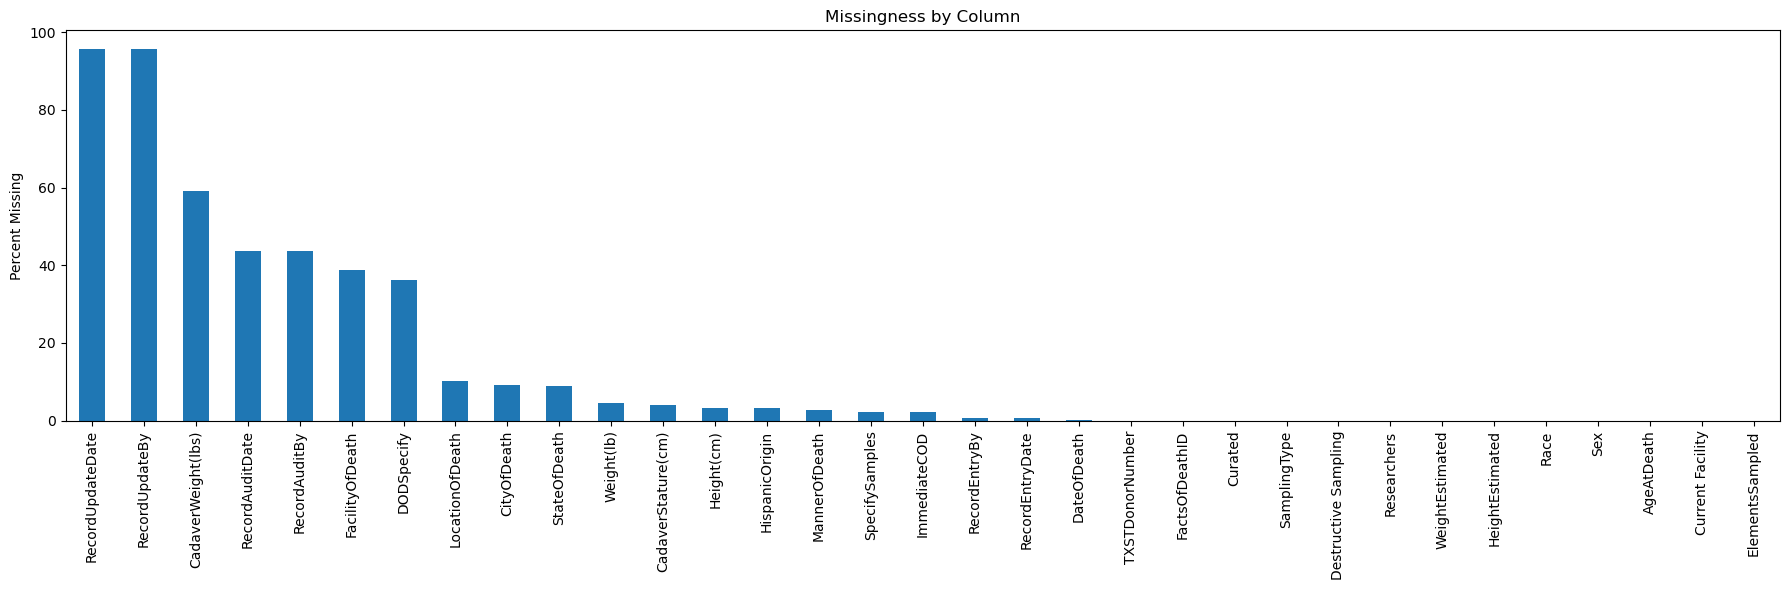

In [15]:
missing_percent = df_merged.isnull().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(18,6))  # <-- wider figure
missing_percent.plot(kind='bar')
plt.xticks(rotation=90)
plt.ylabel('Percent Missing')
plt.title('Missingness by Column')
plt.tight_layout()
plt.show()

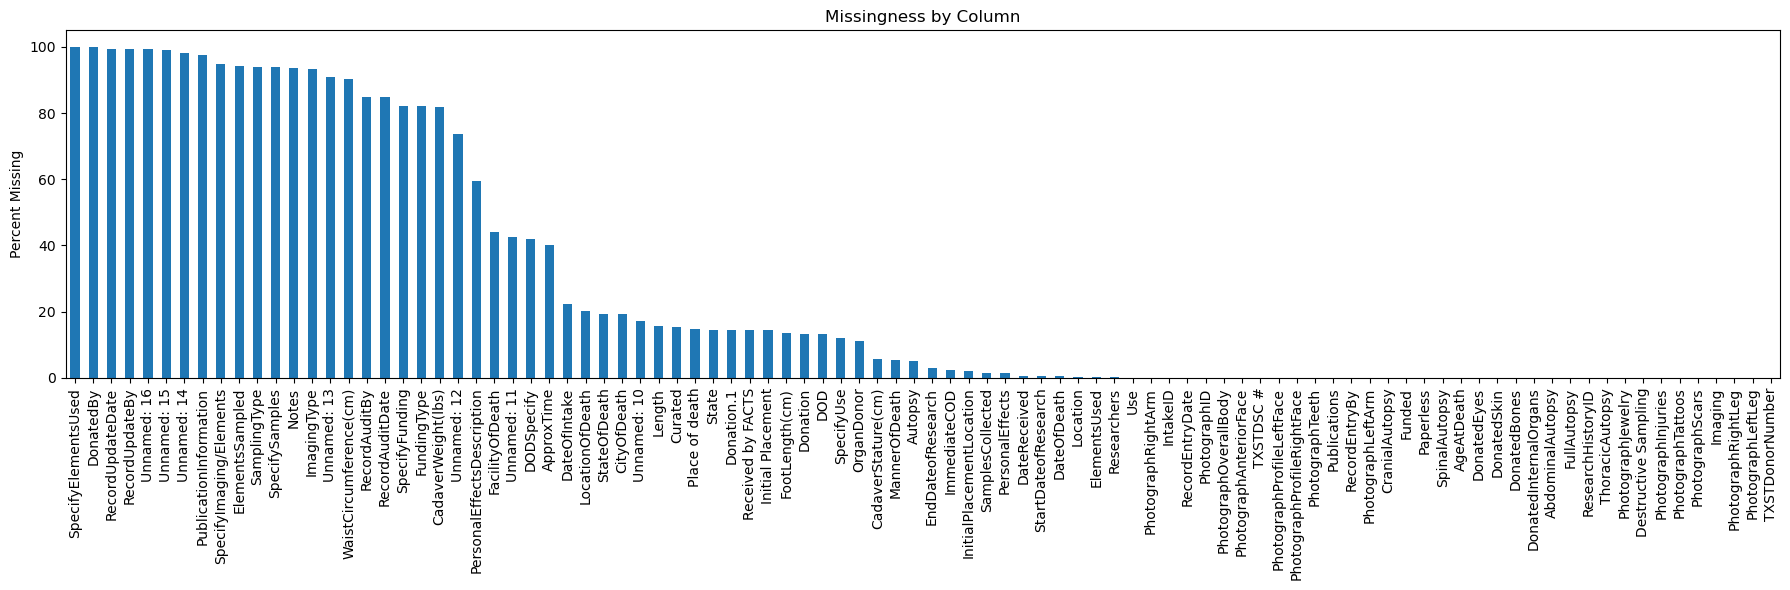

In [16]:
missing_percent = df_merged_2.isnull().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(18,6))  # <-- wider figure
missing_percent.plot(kind='bar')
plt.xticks(rotation=90)
plt.ylabel('Percent Missing')
plt.title('Missingness by Column')
plt.tight_layout()
plt.show()